In [1]:
#1. Initial Ansalysis

import pandas as pd

# Load dataset
df = pd.read_csv("Loan prediction.csv")

# 1. Display first 10 records
print("First 10 Records:")
print(df.head(10))

# 2. Features and target variable
features = df.drop("Loan_Status", axis=1).columns
target = "Loan_Status"

print("\nFeatures:")
print(features.tolist())

print("\nTarget Variable:")
print(target)

# 3. Number of records and attributes
print("\nShape of Dataset:")
print(df.shape)

# 4. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 5. Statistical properties
print("\nStatistical Summary:")
print(df.describe())

First 10 Records:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2        

In [2]:
#2. Data Preprocessing

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Loan prediction.csv")

# Drop Loan_ID
df.drop("Loan_ID", axis=1, inplace=True)

# Handle Missing Values

categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Feature Matrix and Target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Matrix Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (614, 11)
Target Shape: (614,)


/tmp/ipykernel_592/867941913.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_592/867941913.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

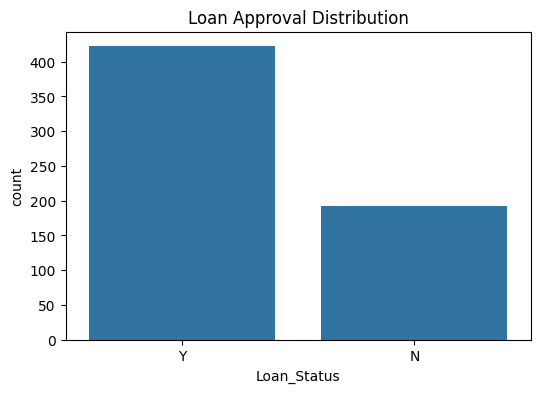

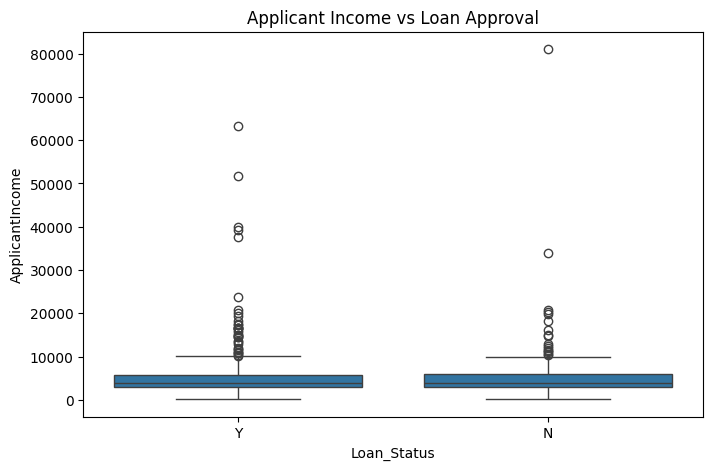

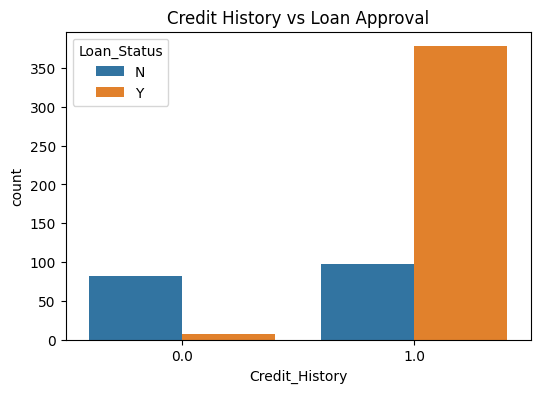

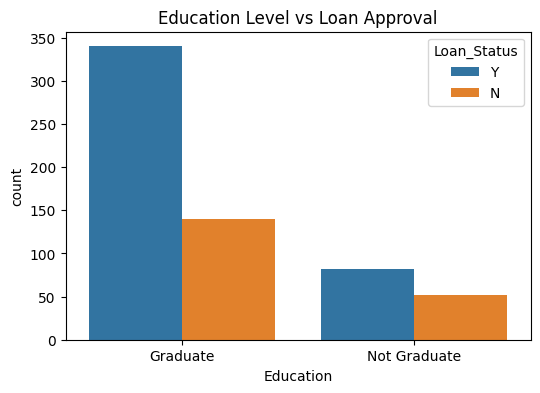

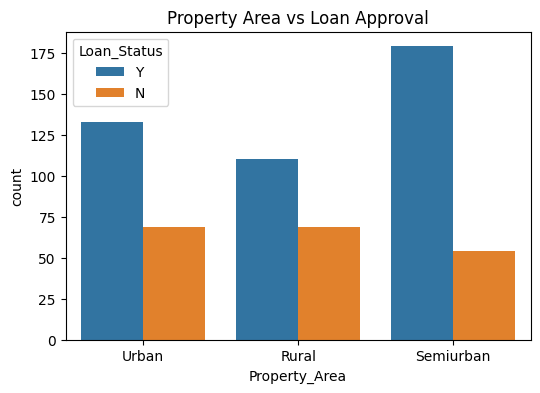

In [3]:
#3. Exploratory Data Analysis (EDA)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Loan prediction.csv")

# Loan Approval Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Applicant Income vs Loan Approval
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Approval")
plt.show()

# Credit History vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

# Education vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education Level vs Loan Approval")
plt.show()

# Property Area vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

In [4]:
#4. Train-Test Split And Model Comparison

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_csv("Loan prediction.csv")

df.drop("Loan_ID", axis=1, inplace=True)

# Missing values
for col in ['Gender','Married','Dependents','Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Encoding
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1 Score']
)

print(results_df)

/tmp/ipykernel_592/469315780.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_592/469315780.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
1        Decision Tree  0.764228   0.825581  0.835294  0.830409
2        Random Forest  0.829268   0.847826  0.917647  0.881356


In [5]:
#5. Best Model Analysis

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
2        Random Forest  0.829268   0.847826  0.917647  0.881356
1        Decision Tree  0.764228   0.825581  0.835294  0.830409


In [6]:
#6. Stratified 5-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring='accuracy'
    )

    print("\n", name)
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std Deviation:", scores.std())


 Logistic Regression
Fold Accuracies: [0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8045981607357058
Std Deviation: 0.025448821062939588

 Decision Tree
Fold Accuracies: [0.68292683 0.73170732 0.70731707 0.65853659 0.72131148]
Mean Accuracy: 0.700359856057577
Std Deviation: 0.0265448033707344

 Random Forest
Fold Accuracies: [0.79674797 0.80487805 0.77235772 0.71544715 0.79508197]
Mean Accuracy: 0.7769025723044115
Std Deviation: 0.03257109584873558


In [7]:
#7. Hyperparameter Turning Using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

print("\nTest Accuracy:")
print(accuracy_score(y_test, pred))

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}

Best CV Score:
0.8004122861265719

Test Accuracy:
0.8536585365853658


In [8]:
from sklearn.metrics import classification_report

# Before tuning
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

pred_before = rf_default.predict(X_test)

# After tuning
pred_after = best_rf.predict(X_test)

print("Before Tuning")
print(classification_report(y_test, pred_before))

print("After Tuning")
print(classification_report(y_test, pred_after))

Before Tuning
              precision    recall  f1-score   support

           0       0.77      0.63      0.70        38
           1       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123

After Tuning
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [9]:
#8. Bias-Variance Tradeoff Usinf Decision Trees

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [2,5,15]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append([
        depth,
        train_acc,
        test_acc
    ])

bias_variance_table = pd.DataFrame(
    results,
    columns=[
        'Max Depth',
        'Training Accuracy',
        'Testing Accuracy'
    ]
)

print(bias_variance_table)

   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.804481          0.853659
1          5           0.824847          0.821138
2         15           0.979633          0.764228
